In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import optimize

import os, sys
sys.path.append(os.path.abspath('../../Software/.'))
import rate_methods_library as RM

In [2]:
barrs = [5,7,9,11,13]
true = 1.4328652141523972e-6
runs = [f"run_{i+1}" for i in range(100)]

In [3]:
log_name = 'p.log'
colvar_name = 'opes_short.colvar'
#runs = [f"run_{i+1}" for i in range(100)]
plog_len = 1
beta = 1. / (312.*0.008314)

poisson_CDF = lambda t, k : 1. - np.exp(-k*t)

def get_data(directory,runs,biascol):
    print(f"{directory}:")
    colvars = []
    plogs = []
    for run in runs:
        colvars.append(f"{directory}/{run}/{colvar_name}")
        plogs.append(f"{directory}/{run}/{log_name}")
    
    # Load all colvar files
    colvars_count = len(colvars)
    colvars_maxrow_count = None
    
    data = [] # data[i][j,k] is column k of simulation i at the time of row j.
    final_times = np.zeros((colvars_count, 2)) # final_times[i,0] is simulation i's transition time while final_times[i,1] is the iMetaD rescaled time.
    i = 0
    for colvar in colvars:
        current_colvar = np.loadtxt(colvar, usecols=[0,biascol])
        data.append(current_colvar)
        colvars_maxrow_count = data[-1].shape[0] if colvars_maxrow_count is None or colvars_maxrow_count < data[-1].shape[0] else colvars_maxrow_count
        final_times[i,:] = np.array([data[-1][-1][0],0])
        i = i+1

    #tracemalloc.stop()
    # Count transitions
    event = []
    for plog in plogs:
        with open(plog,'r') as f:
            if len(f.readlines()) > plog_len:
                event.append(True)
            else:
                event.append(False)
    event = np.array(event)
    M = event.sum() # Number of transitions
    N = len(event) # Total number of simulations
    print(f"{M} out of {N} underbiased simulations transitioned.")

    return data, final_times, colvars_count, colvars_maxrow_count, event

In [4]:
accs_Q = []
ts_Q = []
ks_Q = []

for barr in barrs:
    
    data, final_times, colvars_count, colvars_maxrow_count, event = get_data(f"../../Data/protG/Q_frac_native_contacts_opes/qruns_barr{barr}",runs,3)
    v_data, times = RM.inst_bias(data, beta, bias_shift=np.float64(barr))

    ecdfxs = np.sort(final_times[:,0])[:event.sum()] # This is only valid if all transitions occur before all non-transitioned simulations ended.
    ecdfys = np.linspace(1/100,1,100)[:event.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs,ecdfys,p0=1e-6)[0][0]
    ks_Q.append(emp_rate)
    
    acc_EATR = np.nanmean(np.exp(beta*v_data),axis=0)
    accs_Q.append(acc_EATR)
    ts_Q.append(times)

../../Data/protG/Q_frac_native_contacts_opes/qruns_barr5:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/Q_frac_native_contacts_opes/qruns_barr7:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/Q_frac_native_contacts_opes/qruns_barr9:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/Q_frac_native_contacts_opes/qruns_barr11:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/Q_frac_native_contacts_opes/qruns_barr13:
100 out of 100 underbiased simulations transitioned.


In [5]:
accs_E = []
ts_E = []
ks_E = []

for barr in barrs:
    
    data, final_times, colvars_count, colvars_maxrow_count, event = get_data(f"../../Data/protG/E_end_end_distance_opes/eruns_barr{barr}",runs,4)
    v_data, times = RM.inst_bias(data, beta, bias_shift=np.float64(barr))

    ecdfxs = np.sort(final_times[:,0])[:event.sum()] # This is only valid if all transitions occur before all non-transitioned simulations ended.
    ecdfys = np.linspace(1/100,1,100)[:event.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs,ecdfys,p0=1e-6)[0][0]
    ks_E.append(emp_rate)
    
    acc_EATR = np.nanmean(np.exp(beta*v_data),axis=0)
    accs_E.append(acc_EATR)
    ts_E.append(times)

../../Data/protG/E_end_end_distance_opes/eruns_barr5:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/E_end_end_distance_opes/eruns_barr7:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/E_end_end_distance_opes/eruns_barr9:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/E_end_end_distance_opes/eruns_barr11:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/E_end_end_distance_opes/eruns_barr13:
100 out of 100 underbiased simulations transitioned.


In [6]:
accs_G = []
ts_G = []
ks_G = []

for barr in barrs:
    
    data, final_times, colvars_count, colvars_maxrow_count, event = get_data(f"../../Data/protG/G_radius_of_gyration_opes/gruns_barr{barr}",runs,4)
    v_data, times = RM.inst_bias(data, beta, bias_shift=np.float64(barr))

    ecdfxs = np.sort(final_times[:,0])[:event.sum()] # This is only valid if all transitions occur before all non-transitioned simulations ended.
    ecdfys = np.linspace(1/100,1,100)[:event.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs,ecdfys,p0=1e-6)[0][0]
    ks_G.append(emp_rate)
    
    acc_EATR = np.nanmean(np.exp(beta*v_data),axis=0)
    accs_G.append(acc_EATR)
    ts_G.append(times)

../../Data/protG/G_radius_of_gyration_opes/gruns_barr5:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/G_radius_of_gyration_opes/gruns_barr7:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/G_radius_of_gyration_opes/gruns_barr9:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/G_radius_of_gyration_opes/gruns_barr11:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/G_radius_of_gyration_opes/gruns_barr13:
100 out of 100 underbiased simulations transitioned.


In [7]:
accs_GE = []
ts_GE = []
ks_GE = []

for barr in barrs:
    
    data, final_times, colvars_count, colvars_maxrow_count, event = get_data(f"../../Data/protG/2D_GE_opes/geruns_barr{barr}",runs,5)
    v_data, times = RM.inst_bias(data, beta, bias_shift=np.float64(barr))

    ecdfxs = np.sort(final_times[:,0])[:event.sum()] # This is only valid if all transitions occur before all non-transitioned simulations ended.
    ecdfys = np.linspace(1/100,1,100)[:event.sum()]
    emp_rate = optimize.curve_fit(poisson_CDF,ecdfxs,ecdfys,p0=1e-6)[0][0]
    ks_GE.append(emp_rate)
    
    acc_EATR = np.nanmean(np.exp(beta*v_data),axis=0)
    accs_GE.append(acc_EATR)
    ts_GE.append(times)

../../Data/protG/2D_GE_opes/geruns_barr5:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/2D_GE_opes/geruns_barr7:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/2D_GE_opes/geruns_barr9:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/2D_GE_opes/geruns_barr11:
100 out of 100 underbiased simulations transitioned.
../../Data/protG/2D_GE_opes/geruns_barr13:
100 out of 100 underbiased simulations transitioned.


In [15]:
print(len(accs_Q[4]))

825


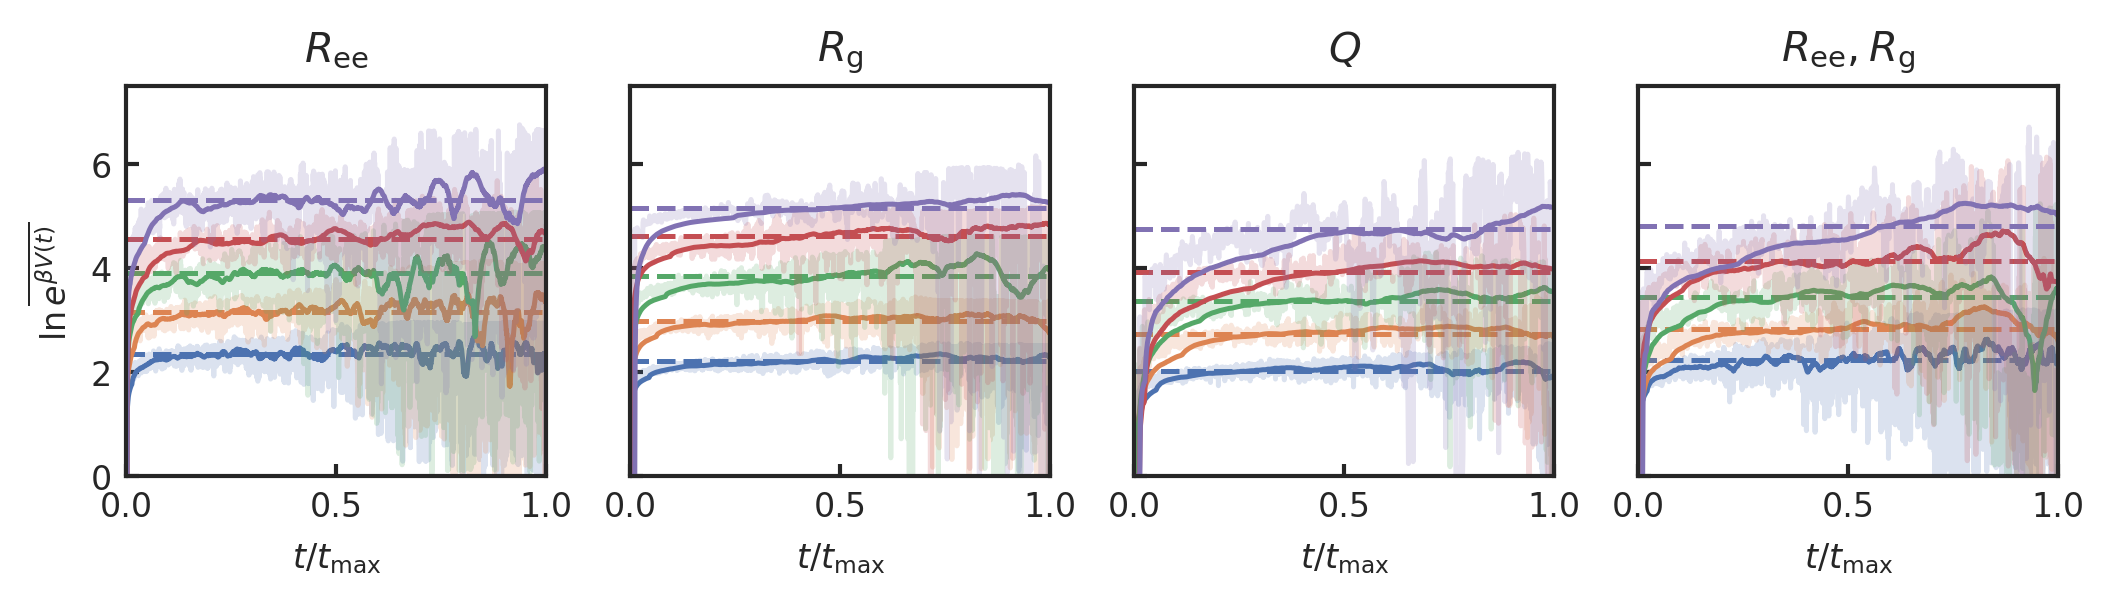

In [17]:
sns.set_theme()
sns.set_style('ticks')
sns.set_context('paper', rc={'axes.labelsize': 8, 'axes.linewidth': 1.0, 'lines.linewidth': 1.2, 'axes.titlesize': 10,
                             'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
                             'legend.fontsize': 6, 'legend.framealpha': 0, 'lines.markersize': 4})

fig, axs = plt.subplots(1,4,figsize=(7,2),dpi=300,sharey=True,sharex=True)
fig.subplots_adjust(wspace=0.2,bottom=0.2,left=0.05,right=0.97,top=0.85)

window = 250
for i, barr in enumerate(barrs):
    axs[0].plot(ts_E[i]/ts_E[i][-1],np.log(accs_E[i]),label=f'Barr {barr}',color=f'C{i}',markersize=2,alpha=0.2)
    axs[0].plot(ts_E[i]/ts_E[i][-1],[np.log(np.mean(accs_E[i][np.max((0,t-window)):t])) for t in range(len(accs_E[i]))],label=f'Barr {barr}',color=f'C{i}',markersize=2)
    axs[0].axhline(np.log(np.mean(accs_E[i])),linestyle='--',color=f'C{i}')
    axs[1].plot(ts_G[i]/ts_G[i][-1],np.log(accs_G[i]),label=f'Barr {barr}',color=f'C{i}',markersize=2,alpha=0.2)
    axs[1].plot(ts_G[i]/ts_G[i][-1],[np.log(np.mean(accs_G[i][np.max((0,t-window)):t])) for t in range(len(accs_G[i]))],label=f'Barr {barr}',color=f'C{i}',markersize=2)
    axs[1].axhline(np.log(np.mean(accs_G[i])),linestyle='--',color=f'C{i}')
    axs[3].plot(ts_GE[i]/ts_GE[i][-1],np.log(accs_GE[i]),label=f'Barr {barr}',color=f'C{i}',markersize=2,alpha=0.2)
    axs[3].plot(ts_GE[i]/ts_GE[i][-1],[np.log(np.mean(accs_GE[i][np.max((0,t-window)):t])) for t in range(len(accs_GE[i]))],label=f'Barr {barr}',color=f'C{i}',markersize=2)
    axs[3].axhline(np.log(np.mean(accs_GE[i])),linestyle='--',color=f'C{i}')
    axs[2].plot(ts_Q[i]/ts_Q[i][-1],np.log(accs_Q[i]),label=f'Barr {barr}',color=f'C{i}',markersize=2,alpha=0.2)
    axs[2].plot(ts_Q[i]/ts_Q[i][-1],[np.log(np.mean(accs_Q[i][np.max((0,t-window)):t])) for t in range(len(accs_Q[i]))],label=f'Barr {barr}',color=f'C{i}',markersize=2)
    axs[2].axhline(np.log(np.mean(accs_Q[i])),linestyle='--',color=f'C{i}')

axs[0].set_ylim((0,7.5))
axs[0].set_xlim((0,1))
axs[0].set_xticks([0,0.5,1])

axs[0].set_ylabel(r'$\ln \overline{ e^{\beta V(t)} }$')
axs[0].set_xlabel(r'$t/t_\mathrm{max}$')
axs[1].set_xlabel(r'$t/t_\mathrm{max}$')
axs[2].set_xlabel(r'$t/t_\mathrm{max}$')
axs[3].set_xlabel(r'$t/t_\mathrm{max}$')

axs[0].set_title(r'$R_\mathrm{ee}$')
axs[1].set_title(r'$R_\mathrm{g}$')
axs[3].set_title(r'$R_\mathrm{ee},R_\mathrm{g}$')
axs[2].set_title(r'$Q$')

for ax in axs.flatten():
    ax.tick_params(axis='both', direction='in', which='both', length=3)

plt.savefig("EATRf_FigS1.pdf",format='pdf')

In [18]:
from scipy import optimize

def EATR_TDR(avg,k0,gamma):
    return np.log(k0) + avg*gamma

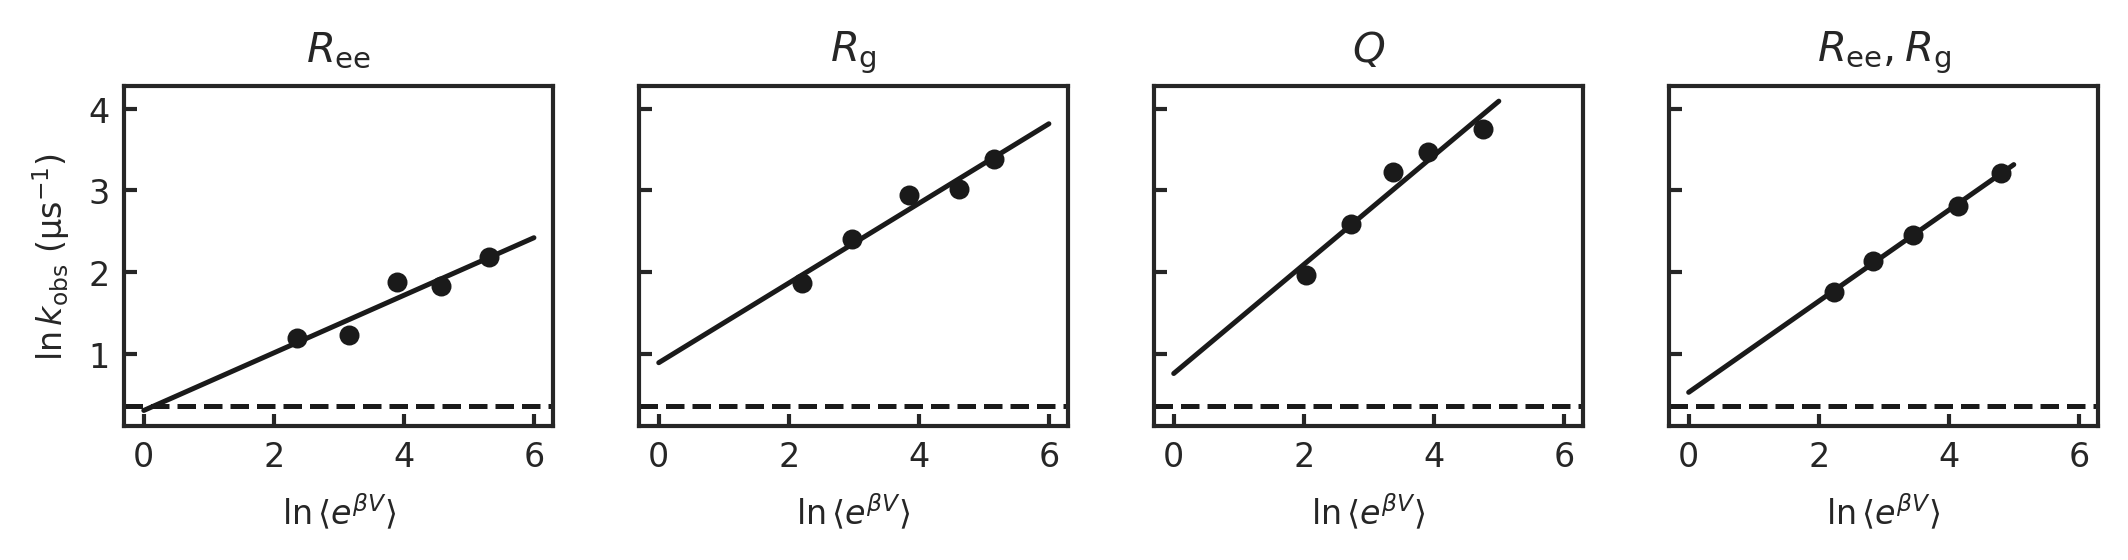

In [22]:
sns.set_theme()
sns.set_style('ticks')
sns.set_context('paper', rc={'axes.labelsize': 8, 'axes.linewidth': 1.0, 'lines.linewidth': 1.2, 'axes.titlesize': 10,
                             'xtick.labelsize': 8, 'ytick.labelsize': 8, 'xtick.major.width': 1.0, 'ytick.major.width': 1.0,
                             'legend.fontsize': 6, 'legend.framealpha': 0, 'lines.markersize': 4})

fig, axs = plt.subplots(1,4,figsize=(7,1.8),dpi=300,sharey=True,sharex=True)
fig.subplots_adjust(wspace=0.2,hspace=0.3,bottom=0.22,left=0.05,right=0.99,top=0.85)

axs[0].axhline(np.log(true)+np.log(1e6),linestyle='--',color='k')
axs[0].scatter(np.log([np.mean(acc) for acc in accs_E]),np.log(ks_E)+np.log(1e6),color='k')
E_k0, E_gamma = optimize.curve_fit(EATR_TDR, np.log([np.mean(acc) for acc in accs_E]), np.log(ks_E)+np.log(1e6), p0=(1e-6,1.0))[0]
x = np.linspace(0,6,5)
axs[0].plot(x, EATR_TDR(x,E_k0,E_gamma),color='k')

axs[1].axhline(np.log(true)+np.log(1e6),linestyle='--',color='k')
axs[1].scatter(np.log([np.mean(acc) for acc in accs_G]),np.log(ks_G)+np.log(1e6),color='k')
G_k0, G_gamma = optimize.curve_fit(EATR_TDR, np.log([np.mean(acc) for acc in accs_G]), np.log(ks_G)+np.log(1e6), p0=(1e-6,1.0))[0]
x = np.linspace(0,6,5)
axs[1].plot(x, EATR_TDR(x,G_k0,G_gamma),color='k')

axs[2].axhline(np.log(true)+np.log(1e6),linestyle='--',color='k')
axs[2].scatter(np.log([np.mean(acc) for acc in accs_Q]),np.log(ks_Q)+np.log(1e6),color='k')
Q_k0, Q_gamma = optimize.curve_fit(EATR_TDR, np.log([np.mean(acc) for acc in accs_Q]), np.log(ks_Q)+np.log(1e6), p0=(1e-6,1.0))[0]
x = np.linspace(0,5,5)
axs[2].plot(x, EATR_TDR(x,Q_k0,Q_gamma),color='k')

axs[3].axhline(np.log(true)+np.log(1e6),linestyle='--',color='k')
axs[3].scatter(np.log([np.mean(acc) for acc in accs_GE]),np.log(ks_GE)+np.log(1e6),color='k')
GE_k0, GE_gamma = optimize.curve_fit(EATR_TDR, np.log([np.mean(acc) for acc in accs_GE]), np.log(ks_GE)+np.log(1e6), p0=(1e-6,1.0))[0]
x = np.linspace(0,5,5)
axs[3].plot(x, EATR_TDR(x,GE_k0,GE_gamma),color='k')

axs[0].set_ylabel(r'$\ln k_\mathrm{obs}~(\mathrm{\mu s}^{-1})$')
axs[0].set_xlabel(r'$\ln\langle e^{\beta V}\rangle$')
axs[1].set_xlabel(r'$\ln\langle e^{\beta V}\rangle$')
axs[2].set_xlabel(r'$\ln\langle e^{\beta V}\rangle$')
axs[3].set_xlabel(r'$\ln\langle e^{\beta V}\rangle$')

axs[0].set_title(r'$R_\mathrm{ee}$')
axs[1].set_title(r'$R_\mathrm{g}$')
axs[2].set_title(r'$Q$')
axs[3].set_title(r'$R_\mathrm{ee},R_\mathrm{g}$')

for ax in axs.flatten():
    ax.tick_params(axis='both', direction='in', which='both', length=3)

plt.savefig("EATRf_FigS2.pdf",format='pdf')

In [21]:
print(f'E: γ = {E_gamma}, k0 = {E_k0}, ln k0 = {np.log(E_k0)}')
print(f'G: γ = {G_gamma}, k0 = {G_k0}, ln k0 = {np.log(G_k0)}')
print(f'Q: γ = {Q_gamma}, k0 = {Q_k0}, ln k0 = {np.log(Q_k0)}')
print(f'GE: γ = {GE_gamma}, k0 = {GE_k0}, ln k0 = {np.log(GE_k0)}')

E: γ = 0.352144641439572, k0 = 1.3603016559834464, ln k0 = 0.3077064810228567
G: γ = 0.4871327555975573, k0 = 2.439470155618612, ln k0 = 0.8917808663881451
Q: γ = 0.6662910521706513, k0 = 2.137453200732583, ln k0 = 0.7596150271949792
GE: γ = 0.5571453955700053, k0 = 1.6978235240532842, ln k0 = 0.5293471508349331
